--- 1. IRIS DATASET ---

[Linear Kernel]
Accuracy Score: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

[RBF Kernel]
Accuracy Score: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


--- 2. LETTER RECOGNITION DATASET ---

Accuracy Score: 0.9305
Confusion Matrix:
 [[144   0   1   0   0   0   1   0   0   0   1   0   1   0   0   0   0   0
    0   0   1   0   0   0   0   0]
 [  0 143   0   5   0   1   0   0   0   0   0   0   0   0   0   0   0   4
    0   0   0   0   0   0   0   0]
 [  0   0 123   0   2   0   3   1   0   0   1   0   0   0   4   0   0   2
    0   0   1   0   0   0   0   0]
 [  0   1   0 153   0   0   0   2   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [  0   3   1   0 130   0   5   0   0   0   0   0   0   0   0   0   1   0
    0   0   0   0   0   0   0   1]
 [  0   2   0   0   1 134   0   0   1   0   0   0   0   0   0   0   0   0
    1   1   0   0   0   0   0   0]
 [  1   0   1   4   0   0 149   0   0   0   2   0   0   

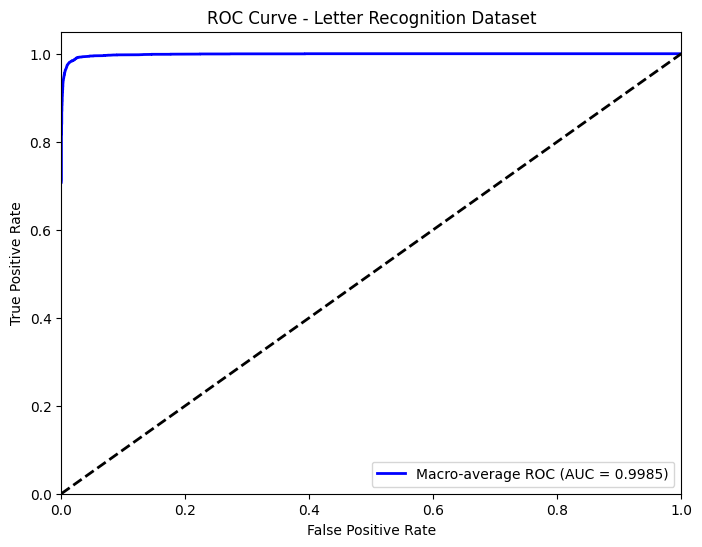

In [6]:
# -*- coding: utf-8 -*-
"""Lab-6-SVM.ipynb"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. IRIS DATASET IMPLEMENTATION
# ==========================================
print("--- 1. IRIS DATASET ---")
# Load the dataset using read_excel
# Make sure the file name exactly matches the one you uploaded to Colab
iris_df = pd.read_excel('iris.xlsx')

# Separate features and target (Adjust 'species' if your column is named differently)
X_iris = iris_df.drop('species', axis=1)
y_iris = iris_df['species']

# 80% Training, 20% Testing
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(X_iris, y_iris, test_size=0.2, random_state=42)

# ---- Linear Kernel ----
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train_iris, y_train_iris)
y_pred_linear = svm_linear.predict(X_test_iris)

print("\n[Linear Kernel]")
print(f"Accuracy Score: {accuracy_score(y_test_iris, y_pred_linear)}")
print("Confusion Matrix:\n", confusion_matrix(y_test_iris, y_pred_linear))

# ---- RBF Kernel ----
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train_iris, y_train_iris)
y_pred_rbf = svm_rbf.predict(X_test_iris)

print("\n[RBF Kernel]")
print(f"Accuracy Score: {accuracy_score(y_test_iris, y_pred_rbf)}")
print("Confusion Matrix:\n", confusion_matrix(y_test_iris, y_pred_rbf))


# ==========================================
# 2. LETTER RECOGNITION DATASET IMPLEMENTATION
# ==========================================
print("\n\n--- 2. LETTER RECOGNITION DATASET ---")
# Load the dataset using read_excel
letter_df = pd.read_excel('letter-recognition.xlsx')

# Separate features and target
X_let = letter_df.drop('letter', axis=1)
y_let = letter_df['letter']

# 80% Training, 20% Testing
X_train_let, X_test_let, y_train_let, y_test_let = train_test_split(X_let, y_let, test_size=0.2, random_state=42)

# Build SVM Classifier (RBF kernel is standard for complex non-linear data)
# probability=True is required to calculate AUC and plot ROC curve
svm_letter = SVC(kernel='rbf', probability=True)
svm_letter.fit(X_train_let, y_train_let)

# Predictions
y_pred_let = svm_letter.predict(X_test_let)
y_prob_let = svm_letter.predict_proba(X_test_let)

# Accuracy and Confusion Matrix
acc_let = accuracy_score(y_test_let, y_pred_let)
cm_let = confusion_matrix(y_test_let, y_pred_let)

print(f"\nAccuracy Score: {acc_let}")
print("Confusion Matrix:\n", cm_let)

# ---- ROC Curve and AUC Score ----
# Binarize labels for multi-class ROC computation
classes = svm_letter.classes_
y_test_bin = label_binarize(y_test_let, classes=classes)
n_classes = len(classes)

# Compute Macro-Average AUC Score
auc_score = roc_auc_score(y_test_bin, y_prob_let, multi_class='ovr', average='macro')
print(f"\nAUC Score (Macro-average): {auc_score}")

# Plot Macro-Average ROC curve
fpr = dict()
tpr = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob_let[:, i])

all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes

plt.figure(figsize=(8, 6))
plt.plot(all_fpr, mean_tpr, color='blue', lw=2, label=f'Macro-average ROC (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Letter Recognition Dataset')
plt.legend(loc="lower right")
plt.show()

--- 0. OPTIMAL HYPERPLANE PLOT ---


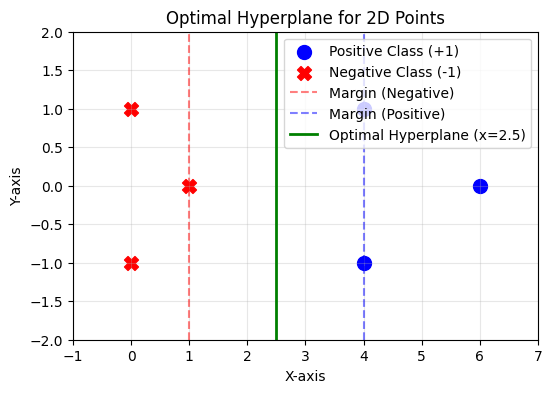


--- 1. IRIS DATASET ---

[Linear Kernel]
Accuracy Score: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

[RBF Kernel]
Accuracy Score: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


--- 2. LETTER RECOGNITION DATASET ---

Accuracy Score: 0.9305
Confusion Matrix:
 [[144   0   1   0   0   0   1   0   0   0   1   0   1   0   0   0   0   0
    0   0   1   0   0   0   0   0]
 [  0 143   0   5   0   1   0   0   0   0   0   0   0   0   0   0   0   4
    0   0   0   0   0   0   0   0]
 [  0   0 123   0   2   0   3   1   0   0   1   0   0   0   4   0   0   2
    0   0   1   0   0   0   0   0]
 [  0   1   0 153   0   0   0   2   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [  0   3   1   0 130   0   5   0   0   0   0   0   0   0   0   0   1   0
    0   0   0   0   0   0   0   1]
 [  0   2   0   0   1 134   0   0   1   0   0   0   0   0   0   0   0   0
    1   1   0   0   0   0   0   0]
 [  1   0   1   4   0   0 149   0   0   0   2   0   0  

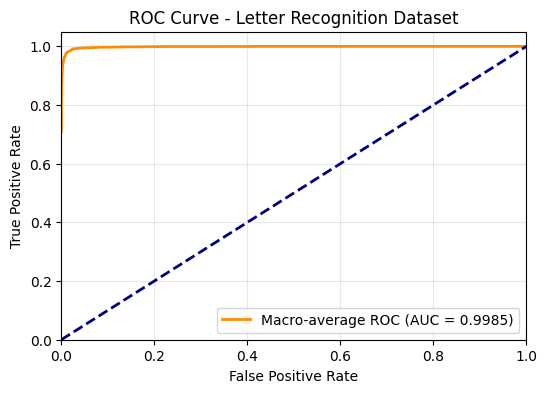

In [7]:
# -*- coding: utf-8 -*-
"""Lab-6-SVM.ipynb"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 0. OPTIMAL HYPERPLANE PLOT (For Observation Book)
# ==========================================
print("--- 0. OPTIMAL HYPERPLANE PLOT ---")
plt.figure(figsize=(6, 4))
pos_x, pos_y = [4, 4, 6], [1, -1, 0]
neg_x, neg_y = [1, 0, 0], [0, 1, -1]

plt.scatter(pos_x, pos_y, color='blue', label='Positive Class (+1)', s=100, marker='o')
plt.scatter(neg_x, neg_y, color='red', label='Negative Class (-1)', s=100, marker='X')

plt.axvline(x=1, color='red', linestyle='--', alpha=0.5, label='Margin (Negative)')
plt.axvline(x=4, color='blue', linestyle='--', alpha=0.5, label='Margin (Positive)')
plt.axvline(x=2.5, color='green', linestyle='-', linewidth=2, label='Optimal Hyperplane (x=2.5)')

plt.xlim(-1, 7)
plt.ylim(-2, 2)
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Optimal Hyperplane for 2D Points')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()


# ==========================================
# 1. IRIS DATASET IMPLEMENTATION
# ==========================================
print("\n--- 1. IRIS DATASET ---")
# Load the dataset using read_excel
iris_df = pd.read_excel('iris.xlsx')

# Separate features and target
X_iris = iris_df.drop('species', axis=1)
y_iris = iris_df['species']

# 80% Training, 20% Testing
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(X_iris, y_iris, test_size=0.2, random_state=42)

# ---- Linear Kernel ----
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train_iris, y_train_iris)
y_pred_linear = svm_linear.predict(X_test_iris)

print("\n[Linear Kernel]")
print(f"Accuracy Score: {accuracy_score(y_test_iris, y_pred_linear)}")
print("Confusion Matrix:\n", confusion_matrix(y_test_iris, y_pred_linear))

# ---- RBF Kernel ----
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train_iris, y_train_iris)
y_pred_rbf = svm_rbf.predict(X_test_iris)

print("\n[RBF Kernel]")
print(f"Accuracy Score: {accuracy_score(y_test_iris, y_pred_rbf)}")
print("Confusion Matrix:\n", confusion_matrix(y_test_iris, y_pred_rbf))


# ==========================================
# 2. LETTER RECOGNITION DATASET IMPLEMENTATION
# ==========================================
print("\n\n--- 2. LETTER RECOGNITION DATASET ---")
# Load the dataset using read_excel
letter_df = pd.read_excel('letter-recognition.xlsx')

# Separate features and target
X_let = letter_df.drop('letter', axis=1)
y_let = letter_df['letter']

# 80% Training, 20% Testing
X_train_let, X_test_let, y_train_let, y_test_let = train_test_split(X_let, y_let, test_size=0.2, random_state=42)

# Build SVM Classifier (probability=True is required to calculate AUC and plot ROC curve)
svm_letter = SVC(kernel='rbf', probability=True)
svm_letter.fit(X_train_let, y_train_let)

# Predictions
y_pred_let = svm_letter.predict(X_test_let)
y_prob_let = svm_letter.predict_proba(X_test_let)

# Accuracy and Confusion Matrix
acc_let = accuracy_score(y_test_let, y_pred_let)
cm_let = confusion_matrix(y_test_let, y_pred_let)

print(f"\nAccuracy Score: {acc_let}")
print("Confusion Matrix:\n", cm_let)

# ---- ROC Curve and AUC Score ----
# Binarize labels for multi-class ROC computation
classes = svm_letter.classes_
y_test_bin = label_binarize(y_test_let, classes=classes)
n_classes = len(classes)

# Compute Macro-Average AUC Score
auc_score = roc_auc_score(y_test_bin, y_prob_let, multi_class='ovr', average='macro')
print(f"\nAUC Score (Macro-average): {auc_score}")

# Plot Macro-Average ROC curve
fpr = dict()
tpr = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob_let[:, i])

all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes

plt.figure(figsize=(6, 4))
plt.plot(all_fpr, mean_tpr, color='darkorange', lw=2, label=f'Macro-average ROC (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Letter Recognition Dataset')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()